# Case study: Allen VISp MERFISH sc-SVC cluster reconstruction

## Notebook Guide

REVISE does not require single-thread execution. To reproduce the saved results
as closely as possible, use a single-thread numerical environment.

Run this notebook from the repository root. Download the Allen VISp MERFISH
archive and Tasic cortex reference, prepare both inputs, run three serial
REVISE sc-SVC cluster applications, and plot the complete GA overview and
reconstructed clusters.

| Download | Save as |
| --- | --- |
| [Allen VISp MERFISH archive](https://s3.embl.de/spatialdata/spatialdata-sandbox/merfish_spatialdata_0.7.3a2.dev27+gde3ed360b.zip) | `../REVISE_rebuttal/raw_data/Real_application/MERFISH_Allen_VISp/raw/merfish_spatialdata_0.7.3a2.dev27+gde3ed360b.zip` |
| [Tasic mouse cortex reference](https://exampledata.scverse.org/squidpy/sc_mouse_cortex.h5ad) | `../REVISE_rebuttal/raw_data/Real_application/MERFISH_Allen_VISp/raw/sc_mouse_cortex.h5ad` |

The reference is matched by species and cortex region, not by cell, animal,
specimen, or experiment. The three retained PNGs are the existing gallery snapshots.


In [ ]:
import os
import subprocess
import sys

SEED = 42

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(SEED)

REPO_ROOT = os.path.abspath(os.getcwd())
APP_ROOT = os.path.abspath(os.path.join(
    REPO_ROOT, "..", "REVISE_rebuttal", "raw_data", "Real_application"
))
CASE_ROOT = os.path.join(APP_ROOT, "MERFISH_Allen_VISp")
TACCO_CASE_DIR = os.path.join(REPO_ROOT, "reproduce", "case", "tacco")
PREPARE_SCRIPT = os.path.join(TACCO_CASE_DIR, "prepare_cases.py")


## 1. Prepare source identities

Preparation runs the explicit Allen converter through `prepare_cases.py` and
then reads the prepared H5AD objects.  The archive is paired with an external
Tasic cortex reference by species and region only; no cell, animal, specimen,
or experiment pairing is claimed.


In [ ]:
subprocess.run(
    [sys.executable, PREPARE_SCRIPT, "allen_visp", "--case-root", CASE_ROOT],
    cwd=REPO_ROOT,
    check=True,
)
ST_PATH = os.path.join(CASE_ROOT, "prepared", "MERFISH.h5ad")
REFERENCE_PATH = os.path.join(
    CASE_ROOT, "prepared", "Tasic2018_sc_mouse_cortex.h5ad"
)
raw_st = ad.read_h5ad(ST_PATH)
reference = ad.read_h5ad(REFERENCE_PATH)


## 2. Run three formal TACCO-backed sc-SVC applications serially


In [ ]:
CONFIG_PATH = os.path.join(
    TACCO_CASE_DIR, "configs", "MERFISH_Allen_VISp_sc_SVC_cluster.yaml"
)
SELECTED_TYPES = ("Glutamatergic", "GABAergic", "Non-Neuronal")


In [ ]:
output_paths = {}
for broad in SELECTED_TYPES:
    output_dir = os.path.join(CASE_ROOT, "results", broad)
    spatial_path = os.path.join(output_dir, "spatial.h5ad")
    expr_path = os.path.join(output_dir, "expr.h5ad")
    command = [
        sys.executable,
        os.path.join(REPO_ROOT, "reconstruct.py"),
        "--config",
        CONFIG_PATH,
        "--select-ct",
        broad,
    ]
    subprocess.run(command, cwd=CASE_ROOT, check=True)
    spatial_output = ad.read_h5ad(spatial_path)
    expr_output = ad.read_h5ad(expr_path)
    output_paths[broad] = {
        "spatial": spatial_output,
        "expr": expr_output,
    }


## 3. Complete GA overview: expression UMAP and measured-space map

The exact route-level TACCO GA operation is repeated once on the complete
preprocessed target for an overview of all broad labels.  This in-memory
diagnostic is not an additional published artifact.


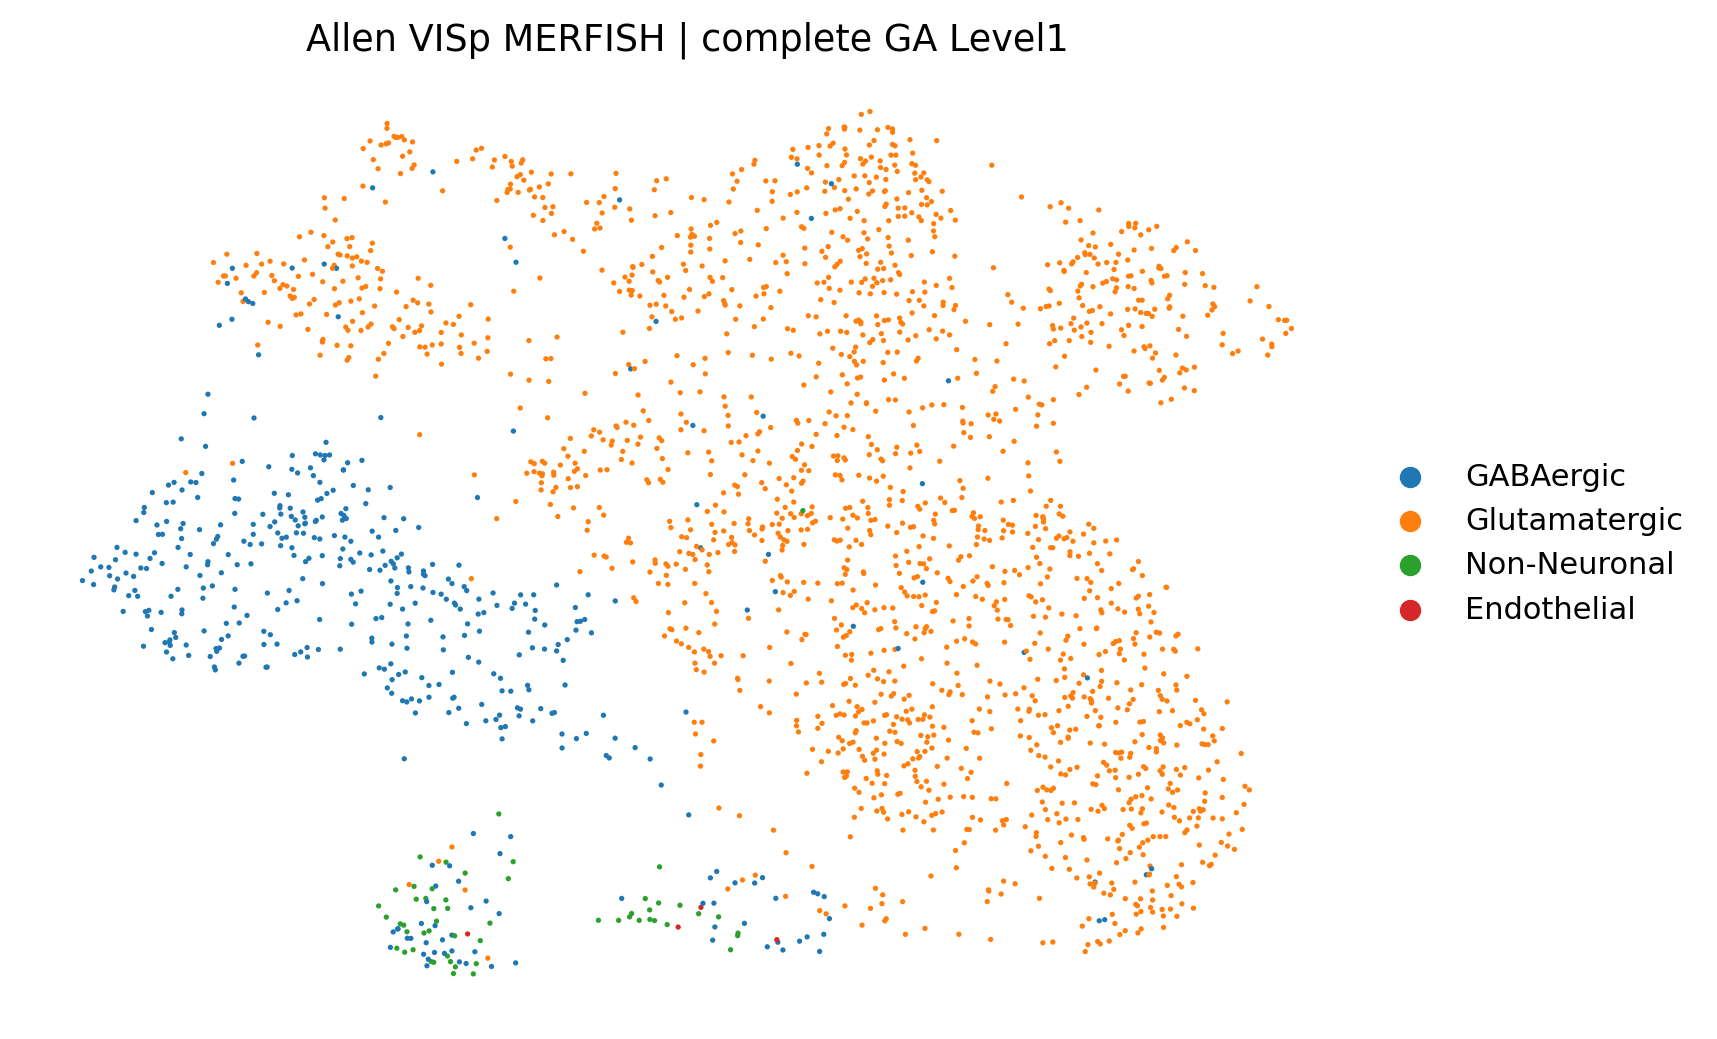

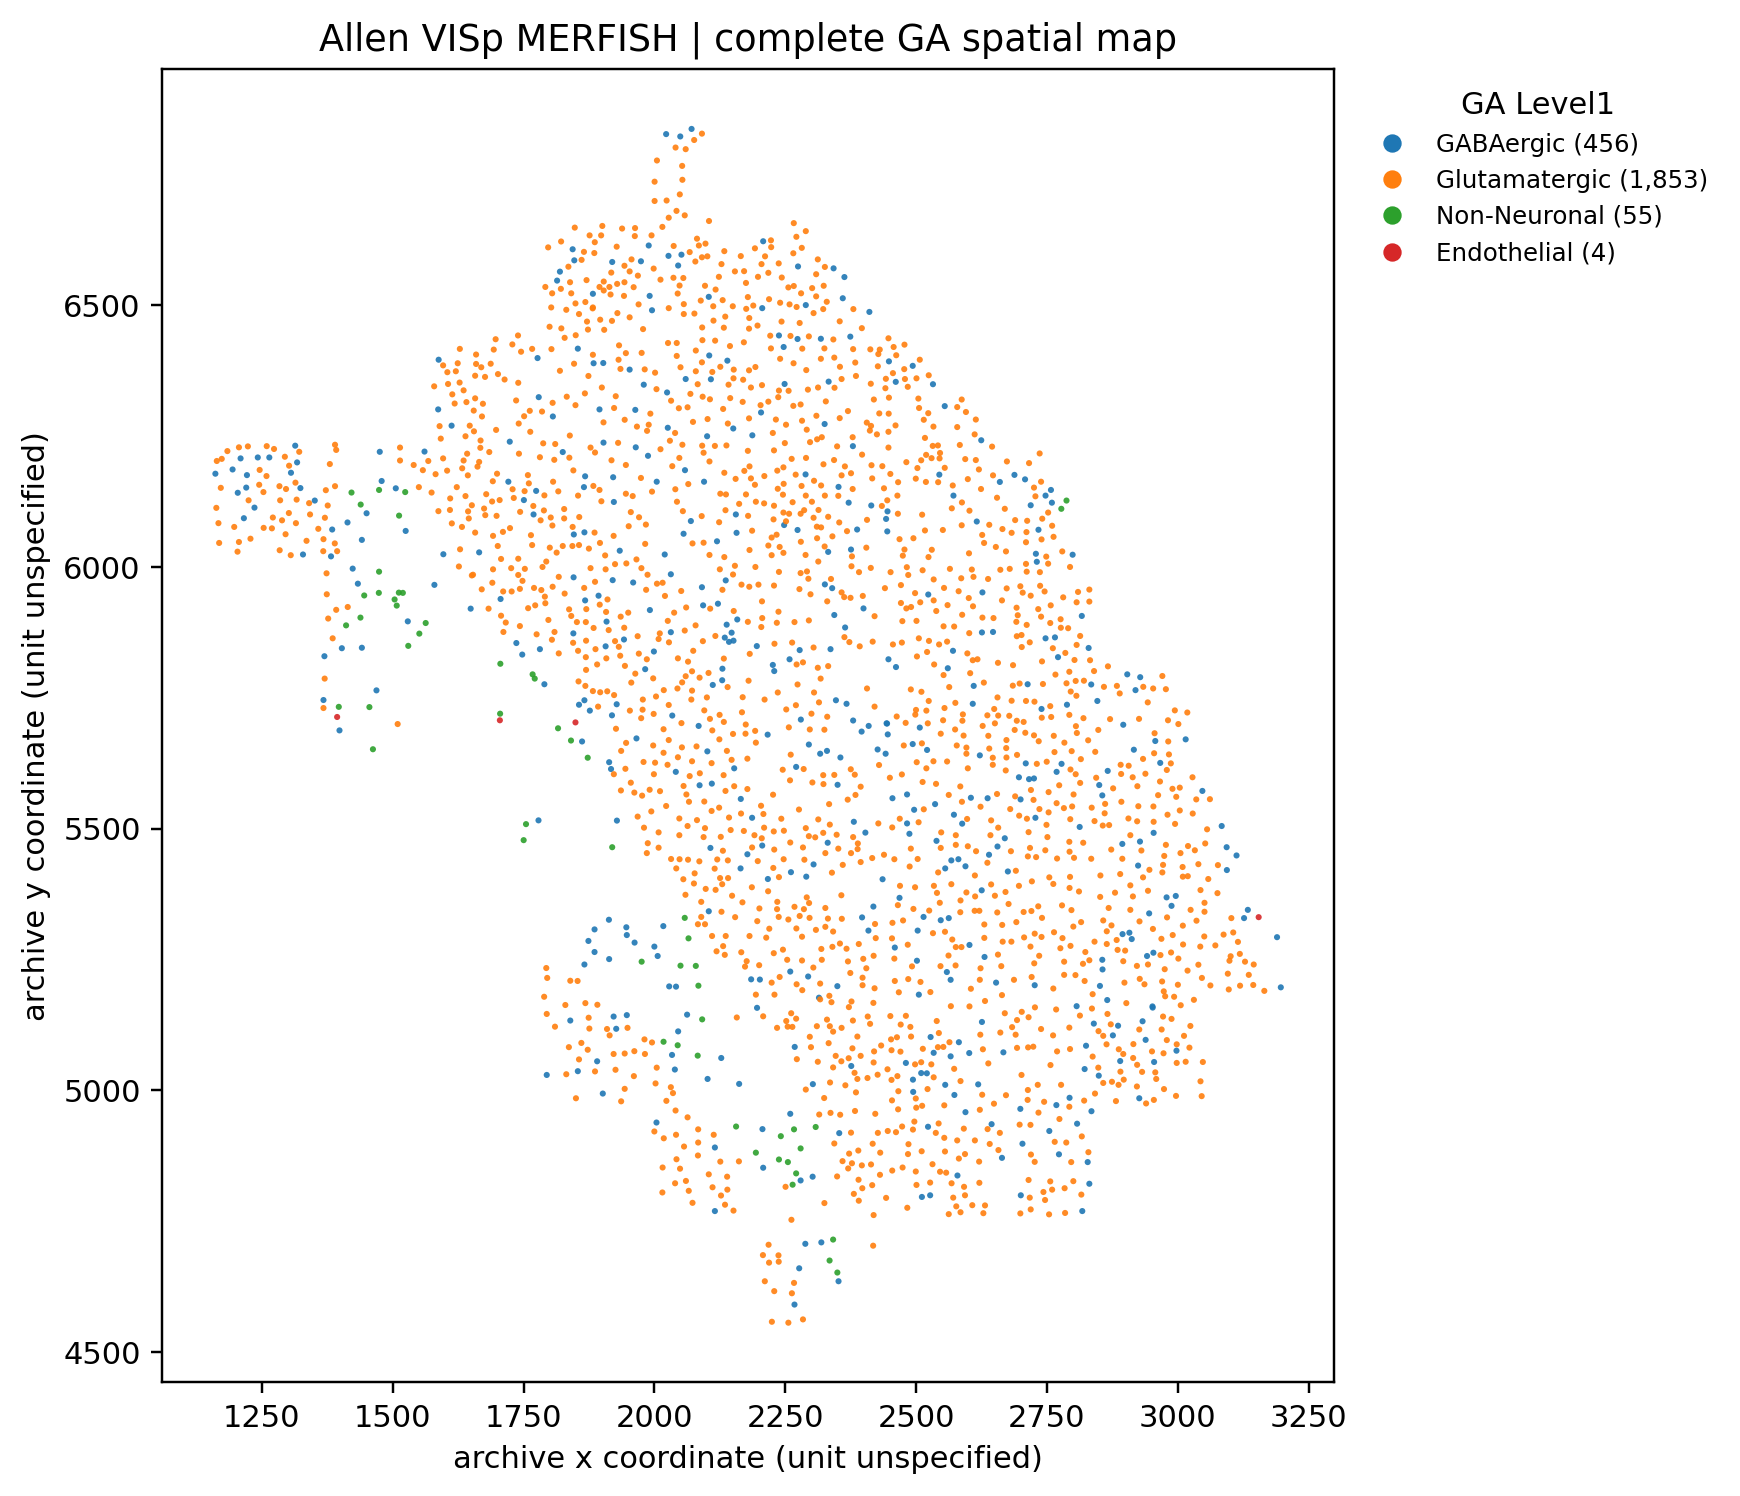

In [ ]:
import scanpy as sc
import pandas as pd
from reconstruct import preprocess_data
from revise.application.config import compile_application_config, load_application_yaml
from revise.backend.kernels.ot import OTKernel
from revise.config import ENGINE_DEFAULTS, ROUTES
from revise.utils.deterministic import set_global_seed

config_source, config_document = load_application_yaml(CONFIG_PATH)
app_config = compile_application_config(
    config_document, source=config_source, cwd=CASE_ROOT
)
full_spatial, full_reference = preprocess_data(
    raw_st.copy(), reference.copy(), app_config
)
route_overrides = ROUTES["application"]["sc-SVC:cluster"].overrides
ga_method = route_overrides["ot"]["ga"]["solver"]
tacco_parameters = route_overrides["sc"]["tacco_annotate"]
confidence_key = ENGINE_DEFAULTS["columns"]["confidence_col"]
unknown_key = ENGINE_DEFAULTS["columns"]["unknown_key"]
set_global_seed(SEED)
ga_spatial = OTKernel.annotate(
    full_spatial,
    full_reference,
    method=ga_method,
    annotation_key=app_config.broad_column,
    confidence_key=confidence_key,
    unknown_key=unknown_key,
    **tacco_parameters,
)
broad_order = list(pd.unique(
    full_reference.obs[app_config.broad_column].astype(str)
))
ga_labels = ga_spatial.obs[app_config.broad_column].astype(str)
selected_spatial = {
    broad: output_paths[broad]["spatial"] for broad in SELECTED_TYPES
}
observed_broad = [
    label for label in broad_order if label in set(ga_labels)
]
broad_palette = plt.get_cmap("tab10").colors
broad_colors = {
    label: broad_palette[index % len(broad_palette)]
    for index, label in enumerate(observed_broad)
}
ga_umap = ga_spatial.copy()
sc.pp.normalize_total(ga_umap, target_sum=1e4)
sc.pp.log1p(ga_umap)
sc.pp.pca(ga_umap, n_comps=30, random_state=SEED)
sc.pp.neighbors(ga_umap, n_neighbors=15, n_pcs=30, random_state=SEED)
sc.tl.umap(ga_umap, random_state=SEED)
fig, ax = plt.subplots(figsize=(7.8, 5.6))
sc.pl.umap(
    ga_umap,
    color=app_config.broad_column,
    size=12,
    title="Allen VISp MERFISH | complete GA Level1",
    frameon=False,
    legend_loc="none",
    ax=ax,
    show=False,
)
coordinates = np.asarray(ga_spatial.obsm["spatial"])
fig, ax = plt.subplots(figsize=(7.8, 7.8), constrained_layout=True)
point_colors = np.asarray([broad_colors[label] for label in ga_labels])
ax.scatter(
    coordinates[:, 0], coordinates[:, 1], s=4, c=point_colors,
    alpha=0.9, linewidths=0, rasterized=True,
)
ax.set_title("Allen VISp MERFISH | complete GA spatial map")
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])
plt.show()


## 4. Transferred Tasic subtypes versus reconstructed SVC clusters

`Level2` is the transferred Tasic subtype and `SVC_cluster` is the formal
reconstructed cluster.  The six panels use shared MERFISH coordinates for
the three selected broad classes and are a within-reconstruction comparison.


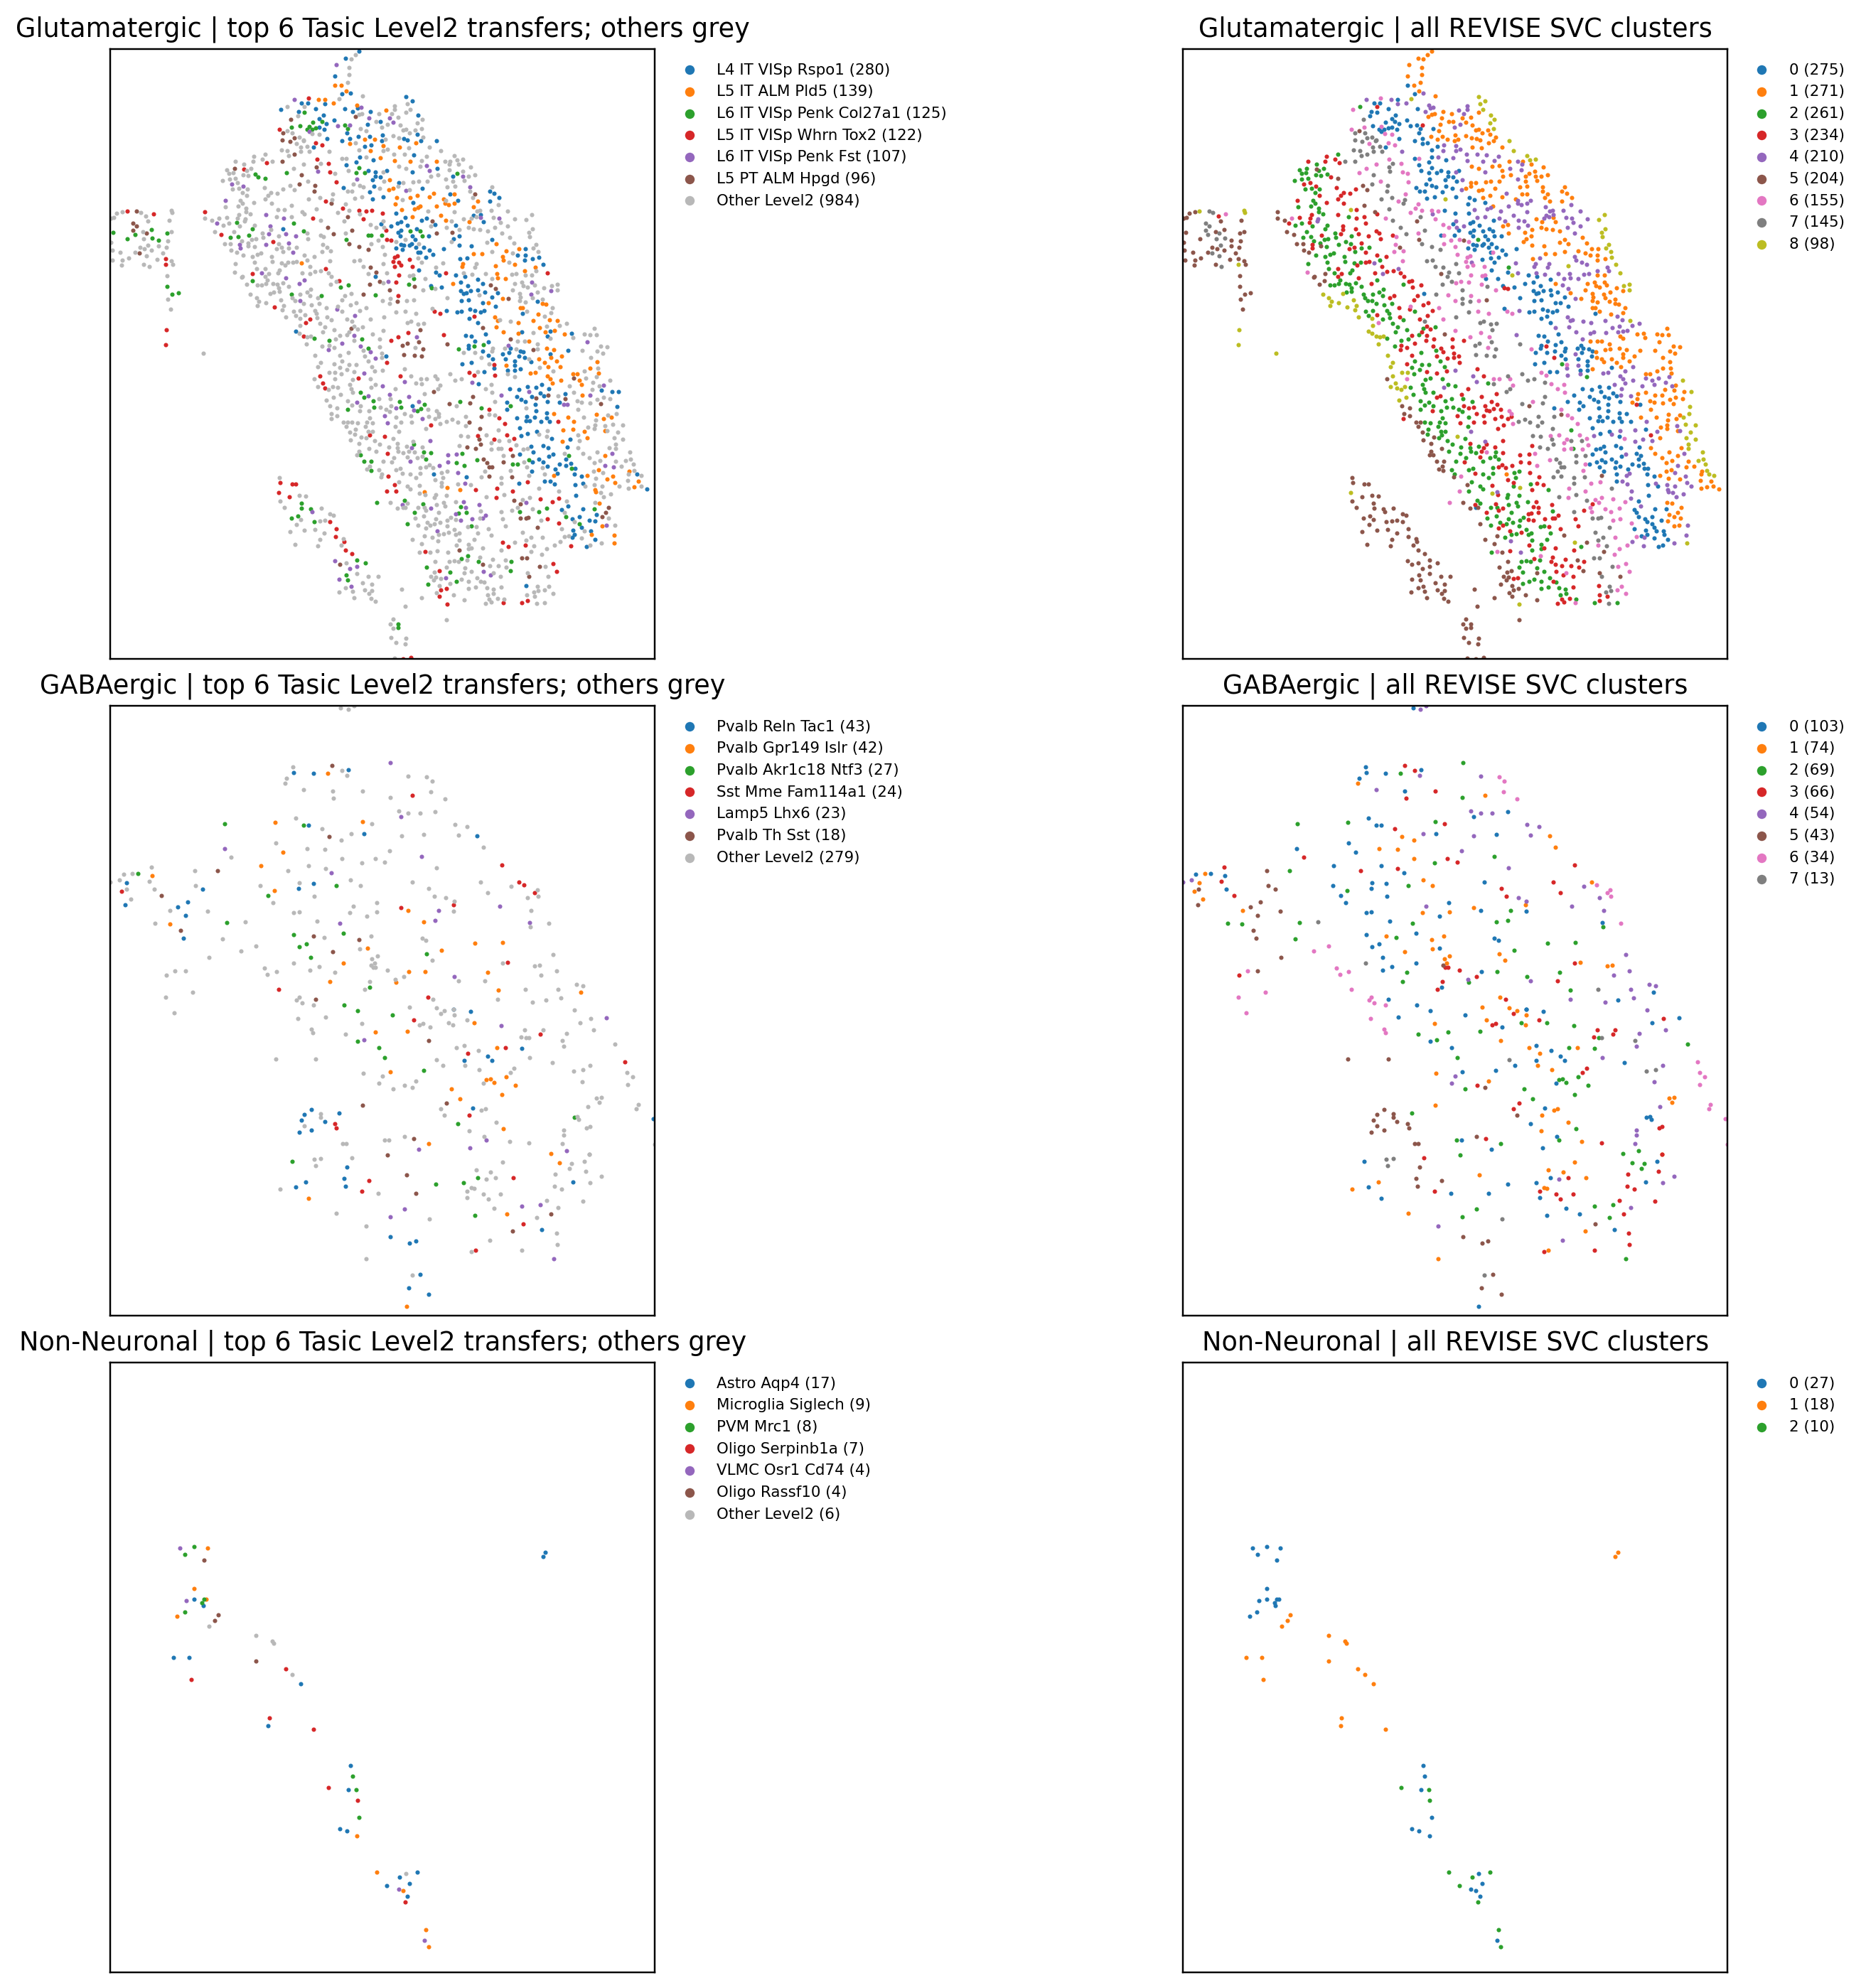

In [ ]:
coordinates = np.asarray(ga_spatial.obsm["spatial"])
x_limits = (float(coordinates[:, 0].min()), float(coordinates[:, 0].max()))
y_limits = (float(coordinates[:, 1].min()), float(coordinates[:, 1].max()))
fig, axes = plt.subplots(
    len(SELECTED_TYPES),
    2,
    figsize=(13, 4.2 * len(SELECTED_TYPES)),
    squeeze=False,
    constrained_layout=True,
)
for row, broad in enumerate(SELECTED_TYPES):
    spatial_output = selected_spatial[broad]
    coords = np.asarray(spatial_output.obsm["spatial"])
    for column, key in enumerate(("Level2", "SVC_cluster")):
        ax = axes[row, column]
        labels = spatial_output.obs[key].astype(str)
        categories = labels.value_counts().index.tolist()
        palette = plt.get_cmap("tab10").colors
        for index, label in enumerate(categories):
            selected = labels.to_numpy() == label
            ax.scatter(
                coords[selected, 0],
                coords[selected, 1],
                s=4,
                color=palette[index % len(palette)],
                linewidths=0,
                rasterized=True,
            )
        ax.set_title(f"{broad} | {key}")
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()
